# 02 - Temperature (TerraClimate)

Operationalize TerraClimate temperature features and run EDA.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

In [ ]:
# Locate repo root early so we can import src modules.

def _find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for parent in [start] + list(start.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError("Could not locate repo root. Run from within the repo.")


REPO_ROOT = _find_repo_root()
sys.path.append(str(REPO_ROOT / "src"))

from satellites.utils import (
    coverage_report,
    ensure_dir,
    find_repo_root,
    load_ubigeo,
    missingness_table,
    outlier_table,
    plot_corr_heatmap,
    plot_hist_ecdf,
    plot_missingness,
    raster_info,
    read_json,
    safe_read_parquet,
    sample_raster_points,
    select_numeric_columns,
    sum_with_nan,
    write_json,
)

REPO_ROOT = find_repo_root(REPO_ROOT)
np.random.seed(42)

sns.set_theme(style="whitegrid")

In [ ]:
def _show_plot(path: Path, title: str) -> None:
    if not path.exists():
        print(f"[plot missing] {title}: {path}")
        return
    print(f"[plot] {title}: {path}")
    display(Image(filename=str(path)))

## Setup

In [ ]:
RAW_DIR = REPO_ROOT / "data" / "external" / "raw" / "temperature"
RAW_META_PATH = RAW_DIR / "metadata.json"

PROCESSED_DIR = REPO_ROOT / "data" / "external" / "processed"
UBIGEO_PATH = PROCESSED_DIR / "ubigeo_district_capitals.parquet"
UBIGEO_FALLBACK = REPO_ROOT / "data" / "external" / "raw" / "ubigeo" / "ubigeo_distrito.csv"
UBIGEO_PLAN_A = REPO_ROOT / "data" / "external" / "raw" / "ubigeo" / "DD_TB_UBIGEOS.xlsx"

REPORT_DIR = ensure_dir(REPO_ROOT / "reports" / "satellites" / "02_temperature")

RAW_META = read_json(RAW_META_PATH)
FILES = RAW_META.get("files", [])
YEARS = sorted({int(entry["year"]) for entry in FILES if "year" in entry})
TARGET_YEAR = max(YEARS) if YEARS else 2024
BASELINE_YEARS = [min(YEARS)] if YEARS else [TARGET_YEAR]

OUT_PARQUET = PROCESSED_DIR / "temperature_district_features_2023_2024.parquet"
OUT_META = REPORT_DIR / "temperature_metadata.json"
QA_SUMMARY_PATH = REPORT_DIR / "qa_summary.json"

## Load UBIGEO and raw metadata

In [ ]:
ubigeo = load_ubigeo(UBIGEO_PATH, UBIGEO_FALLBACK, fallback_excel=UBIGEO_PLAN_A, write_back=True)

print(f"UBIGEO rows: {len(ubigeo)}")
print("Missing capital coordinates:", ubigeo[["capital_lat", "capital_lon"]].isna().any(axis=1).sum())
print("Years available:", YEARS)

UBIGEO rows: 1892
Missing capital coordinates: 18
Years available: [2023, 2024]


## Load + Raw QA

In [ ]:

def tmax_path(year: int) -> Path:
    return RAW_DIR / f"terraclimate_tmax_{year}_peru.nc"


def tmin_path(year: int) -> Path:
    return RAW_DIR / f"terraclimate_tmin_{year}_peru.nc"


missing = []
for year in YEARS:
    if not tmax_path(year).exists():
        missing.append(tmax_path(year))
    if not tmin_path(year).exists():
        missing.append(tmin_path(year))

if missing:
    raise FileNotFoundError(f"Missing TerraClimate files (showing up to 5): {missing[:5]}")

sample_info = raster_info(tmax_path(TARGET_YEAR))
print("Sample tmax raster info:", sample_info)

# Basic data contract checks
if sample_info["count"] < 1:
    raise ValueError("TerraClimate dataset has no bands.")

if sample_info["bounds"] is None or sample_info["res"] is None:
    raise ValueError("TerraClimate raster bounds/resolution metadata missing.")

if sample_info["crs"] is None:
    print("Warning: TerraClimate CRS is None; assuming WGS84 from metadata tags.")

if sample_info["nodata"] is None:
    print("Warning: TerraClimate nodata is None; missing values may be under-detected.")

Sample tmax raster info: {'crs': None, 'bounds': BoundingBox(left=-81.99999999999999, bottom=-19.04166666666665, right=-67.95833333333331, top=1.0000000000000047), 'res': (0.041666666666666664, 0.04166666666666664), 'nodata': -32768.0, 'dtype': 'int16', 'count': 1, 'shape': (481, 337)}


## Operationalization / Pre-processing

In [ ]:
valid_mask = ubigeo[["capital_lat", "capital_lon"]].notna().all(axis=1).to_numpy()
coords = list(
    zip(
        ubigeo.loc[valid_mask, "capital_lon"].astype(float),
        ubigeo.loc[valid_mask, "capital_lat"].astype(float),
    )
)


def sample_year(path: Path) -> np.ndarray:
    values = sample_raster_points(path, coords)
    if values.size == 0:
        return np.full((len(ubigeo), 1), np.nan)
    full = np.full((len(ubigeo), values.shape[1]), np.nan)
    full[valid_mask, :] = values
    return full


outputs: dict[str, np.ndarray | pd.Series] = {"ubigeo6": ubigeo["ubigeo6"].astype("string")}
quarterly_features: dict[str, np.ndarray] = {}

for year in YEARS:
    tmax_vals = sample_year(tmax_path(year))
    tmin_vals = sample_year(tmin_path(year))
    if tmax_vals.shape[1] != tmin_vals.shape[1]:
        raise ValueError(f"Band count mismatch for {year}: tmax={tmax_vals.shape[1]} tmin={tmin_vals.shape[1]}")
    tmean_vals = (tmax_vals + tmin_vals) / 2.0

    tmax_mean = np.nanmean(tmax_vals, axis=1)
    tmin_mean = np.nanmean(tmin_vals, axis=1)
    tmean_mean = np.nanmean(tmean_vals, axis=1)

    outputs[f"tmax_{year}"] = tmax_mean
    outputs[f"tmin_{year}"] = tmin_mean
    outputs[f"tmean_{year}"] = tmean_mean

    # Quarterly means if monthly bands are available
    if tmean_vals.shape[1] >= 12:
        quarters = {
            "q1": [0, 1, 2],
            "q2": [3, 4, 5],
            "q3": [6, 7, 8],
            "q4": [9, 10, 11],
        }
        for q, idxs in quarters.items():
            key = f"tmean_{q}_{year}"
            quarterly_features[key] = np.nanmean(tmean_vals[:, idxs], axis=1)

outputs.update(quarterly_features)

if 2023 in YEARS and 2024 in YEARS:
    outputs["delta_tmean_24_23"] = outputs["tmean_2024"] - outputs["tmean_2023"]

# Baseline anomalies (tmean)
baseline_means = []
for year in BASELINE_YEARS:
    baseline_means.append(outputs[f"tmean_{year}"])

baseline_stack = np.vstack(baseline_means)
baseline_mean = np.nanmean(baseline_stack, axis=0)
baseline_sd = np.nanstd(baseline_stack, axis=0, ddof=1)

outputs["tmean_baseline_mean"] = baseline_mean
outputs["tmean_baseline_sd"] = baseline_sd

outputs["tmean_anom"] = outputs[f"tmean_{TARGET_YEAR}"] - baseline_mean
outputs["tmean_z"] = np.where(baseline_sd > 0, outputs["tmean_anom"] / baseline_sd, np.nan)

out = pd.DataFrame(outputs)

if not out["ubigeo6"].is_unique:
    raise ValueError("Output ubigeo6 keys are not unique.")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUT_PARQUET, index=False)
print(f"Wrote {OUT_PARQUET}")

meta = {
    "source": RAW_META.get("source", "TerraClimate"),
    "years": YEARS,
    "target_year": TARGET_YEAR,
    "baseline_years": BASELINE_YEARS,
    "units": {
        "tmax": "degC",
        "tmin": "degC",
        "tmean": "degC",
        "tmean_anom": "degC",
        "tmean_z": "z-score",
    },
    "quarterly_means": bool(quarterly_features),
    "nodata": sample_info["nodata"],
    "crs": str(sample_info["crs"]),
    "resolution": sample_info["res"],
}

write_json(OUT_META, meta)

Wrote /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/temperature_district_features_2023_2024.parquet


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_9171/2697330080.py:29: RuntimeWarning: Mean of empty slice
  tmax_mean = np.nanmean(tmax_vals, axis=1)
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_9171/2697330080.py:30: RuntimeWarning: Mean of empty slice
  tmin_mean = np.nanmean(tmin_vals, axis=1)
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_9171/2697330080.py:31: RuntimeWarning: Mean of empty slice
  tmean_mean = np.nanmean(tmean_vals, axis=1)
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_9171/2697330080.py:60: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(baseline_stack, axis=0)
/Users/gabrielsaco/Documents/GitHub/sfa_ciup/venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## QA summary

In [ ]:
missing_table = missingness_table(out)
summary_stats = out[select_numeric_columns(out, exclude=["ubigeo6"])].describe().T[
    ["min", "max", "mean", "std"]
]
coverage_table, missing_keys = coverage_report(out, ubigeo)

qa_summary = {
    "row_count": int(len(out)),
    "ubigeo_unique": bool(out["ubigeo6"].is_unique),
    "missing_keys": missing_keys[:50],
    "missing_key_count": int(len(missing_keys)),
    "missingness": missing_table.to_dict(orient="records"),
    "summary_stats": summary_stats.reset_index().rename(columns={"index": "feature"}).to_dict(orient="records"),
    "coverage": coverage_table.to_dict(orient="records"),
}

write_json(QA_SUMMARY_PATH, qa_summary)
print(f"Wrote {QA_SUMMARY_PATH}")

Wrote /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/02_temperature/qa_summary.json


## EDA outputs

[plot] Missingness by column: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/02_temperature/missingness_plot.png


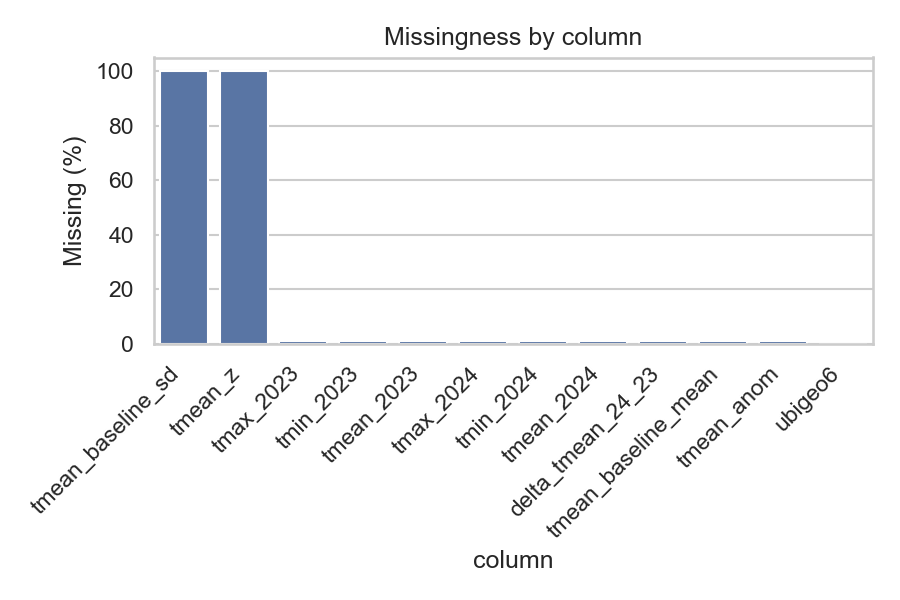

[plot] Feature distributions: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/02_temperature/feature_distributions.png


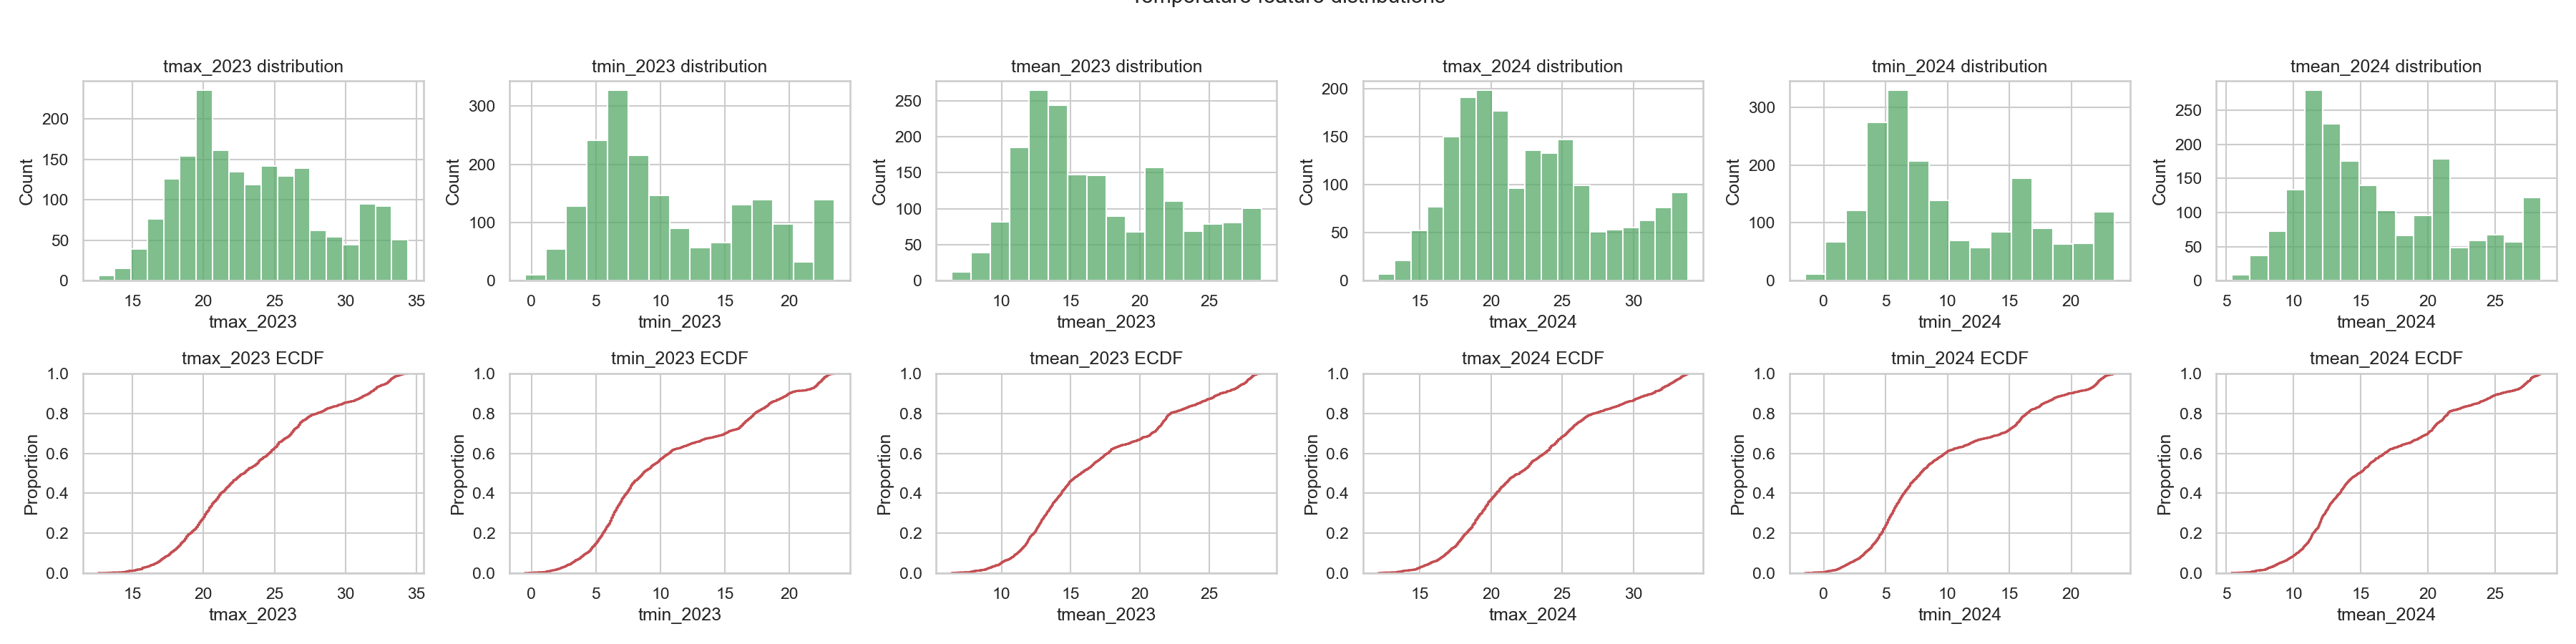

[plot] Temperature correlations: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/02_temperature/corr_temperature_only.png


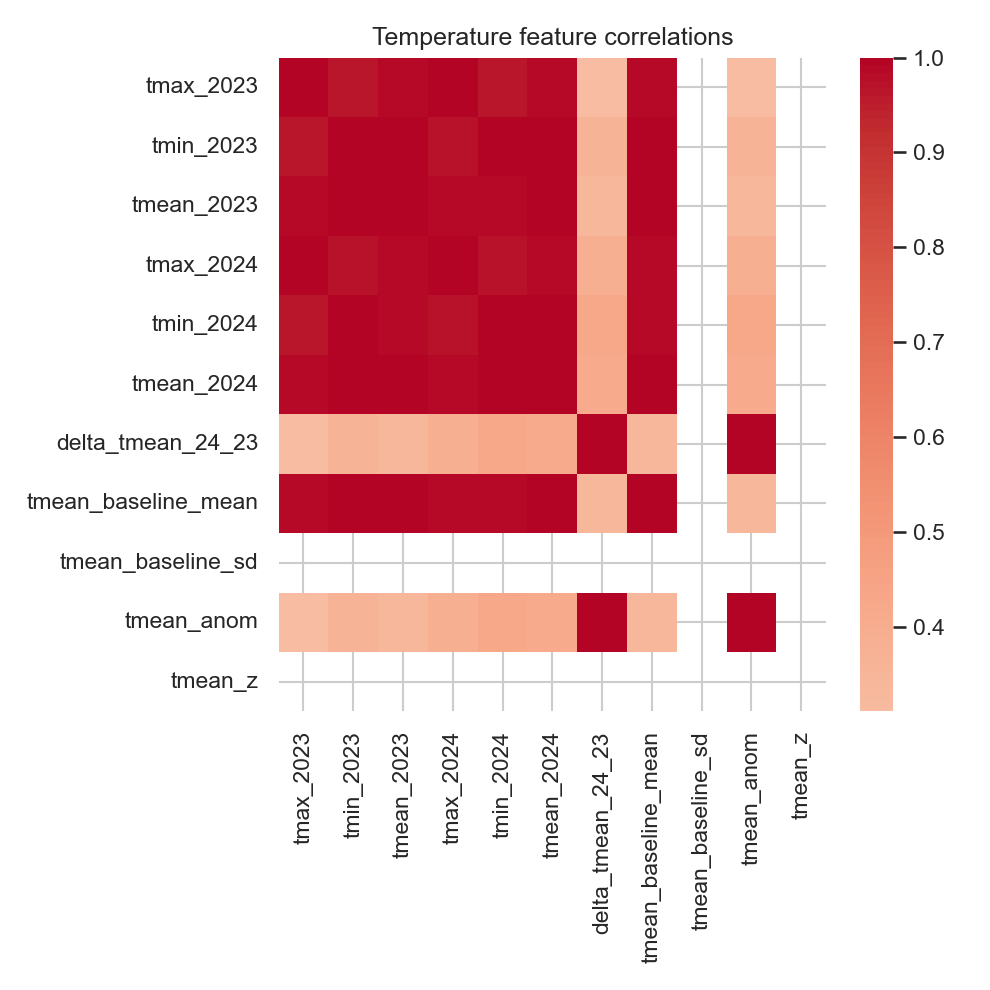

[plot] Temperature + other satellites: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/02_temperature/corr_with_other_satellites.png


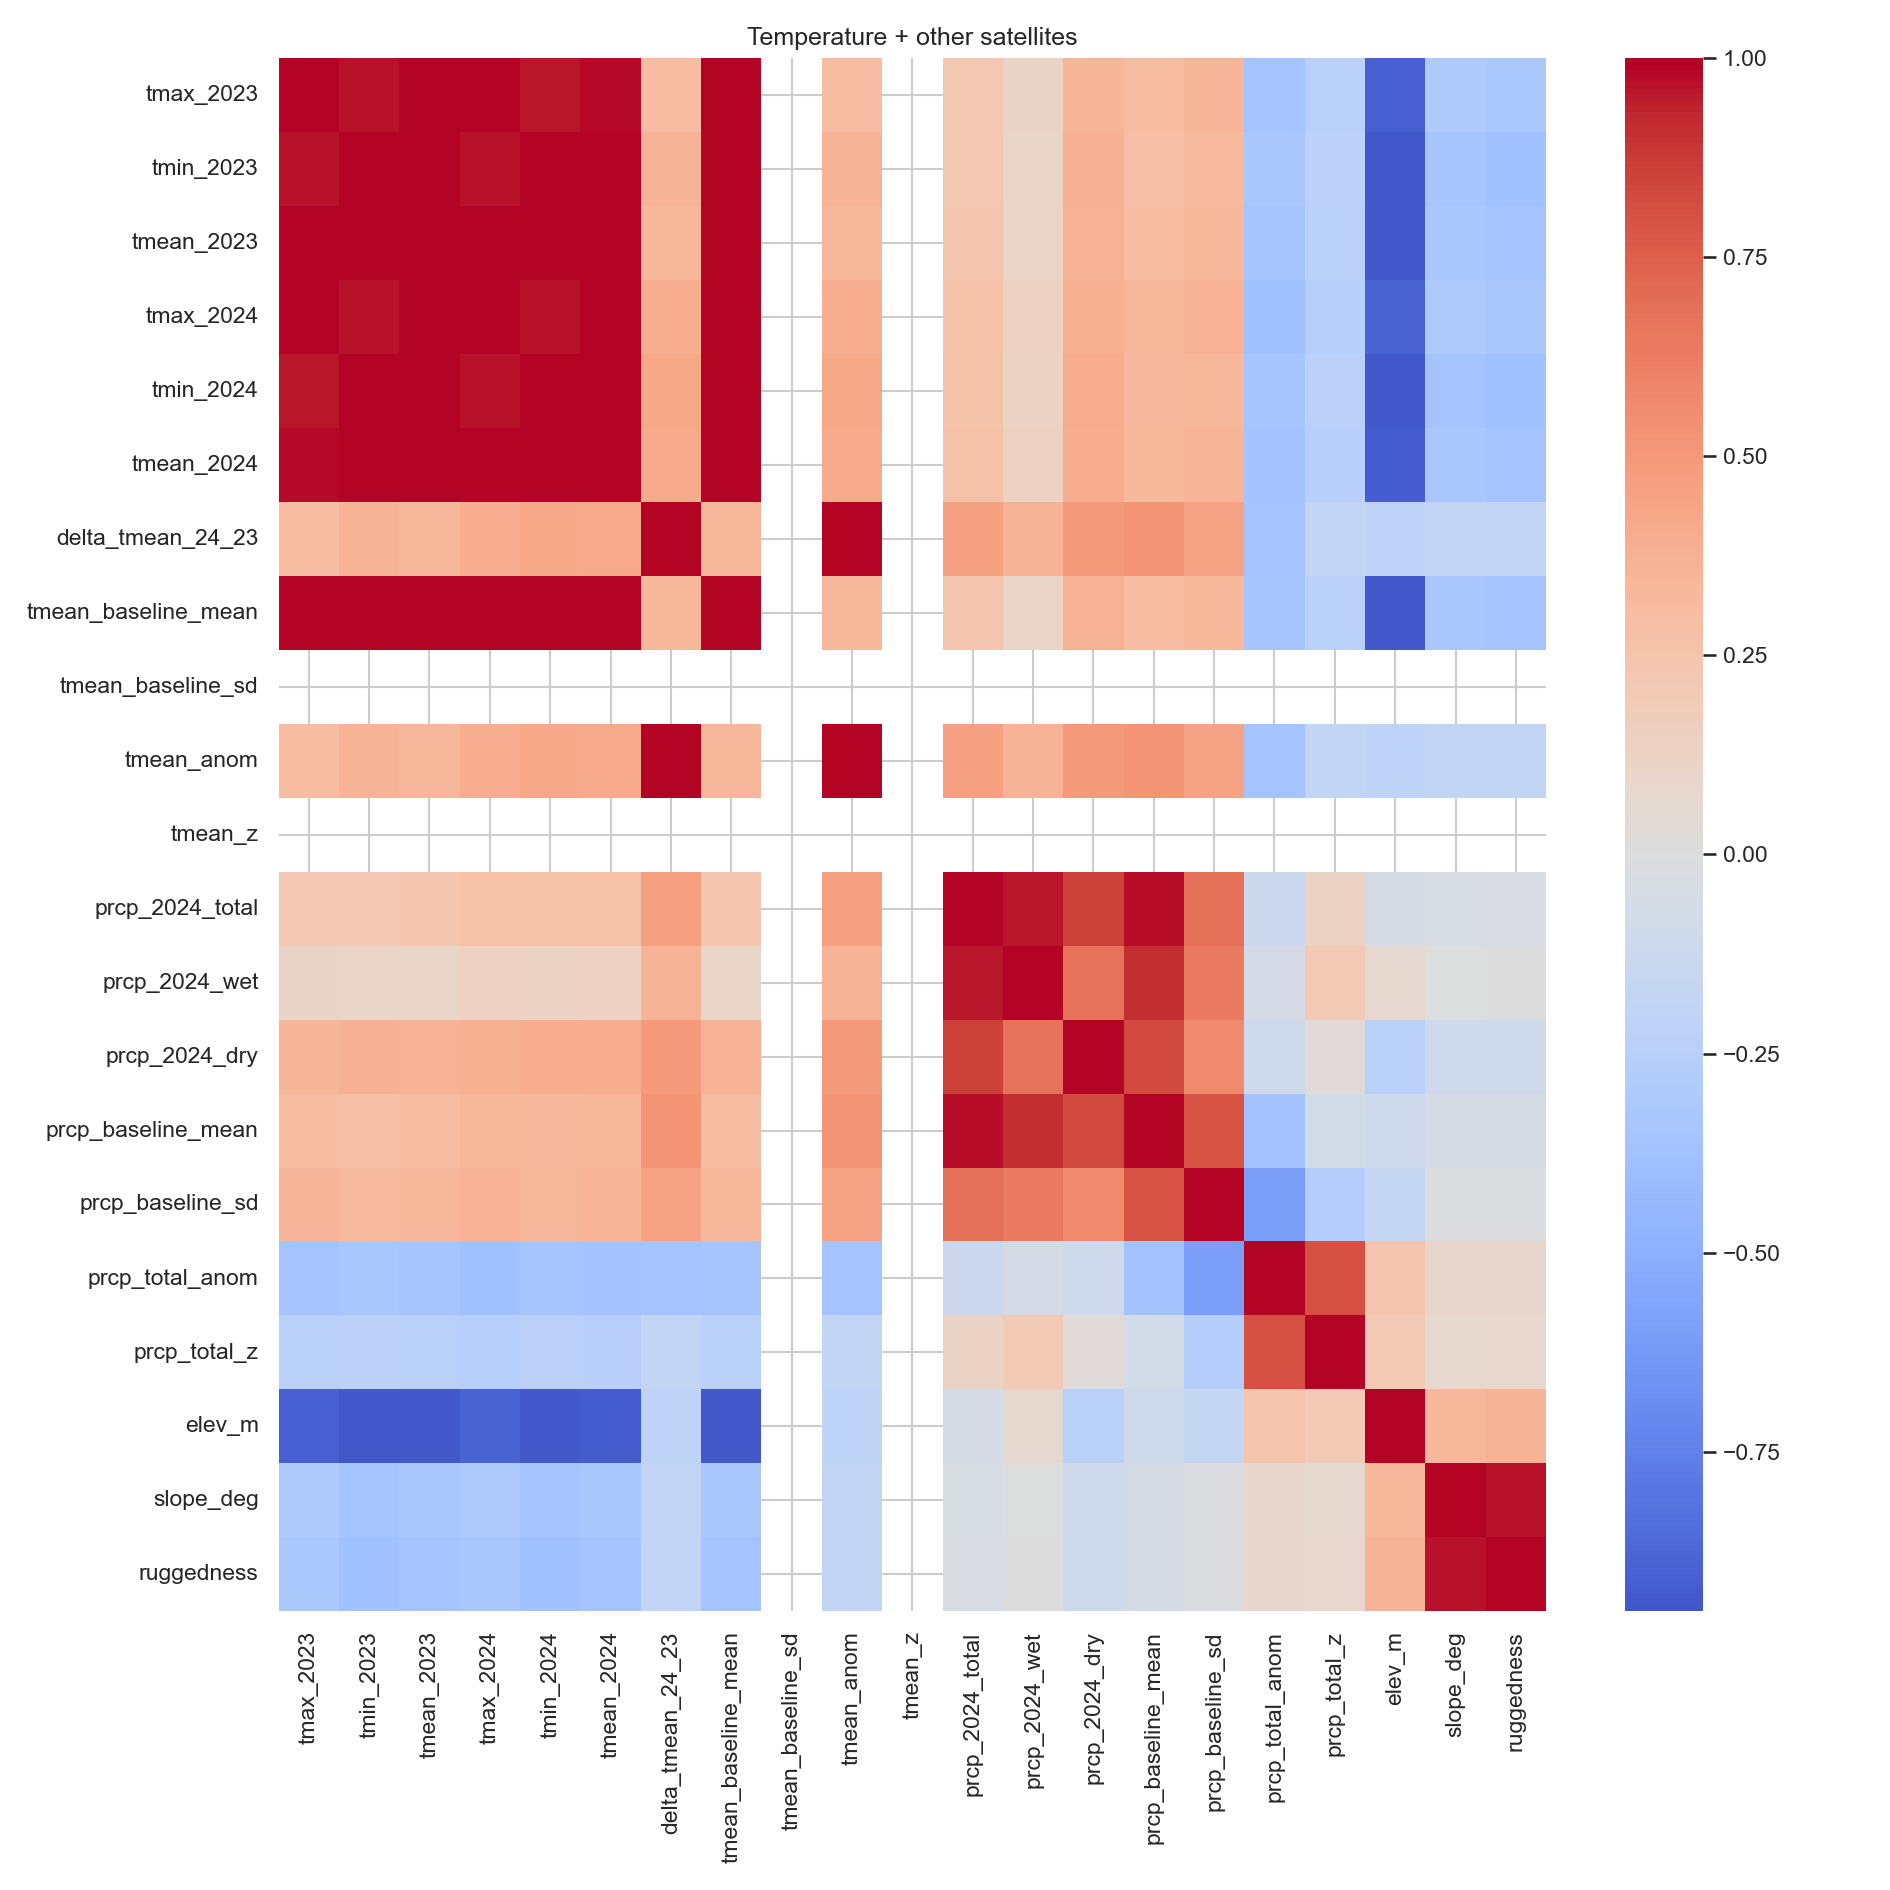

In [ ]:
missing_table_path = REPORT_DIR / "missingness_table.csv"
missing_table.to_csv(missing_table_path, index=False)
plot_missingness(missing_table, REPORT_DIR / "missingness_plot.png", "Missingness by column")
_show_plot(REPORT_DIR / "missingness_plot.png", "Missingness by column")

key_features = [c for c in out.columns if c.startswith("tmean_") or c.startswith("tmax_") or c.startswith("tmin_")]
key_features = [c for c in key_features if c not in {"tmean_baseline_mean", "tmean_baseline_sd"}]
plot_hist_ecdf(out, key_features[:6], REPORT_DIR / "feature_distributions.png", "Temperature feature distributions")
_show_plot(REPORT_DIR / "feature_distributions.png", "Feature distributions")

outliers = outlier_table(out, key_features[:6])
outliers.to_csv(REPORT_DIR / "outliers_top_bottom_20.csv", index=False)

coverage_table.to_csv(REPORT_DIR / "coverage_report.csv", index=False)

# Correlations within temperature features
corr = out[select_numeric_columns(out, exclude=["ubigeo6"])].corr()
plot_corr_heatmap(corr, REPORT_DIR / "corr_temperature_only.png", "Temperature feature correlations")
_show_plot(REPORT_DIR / "corr_temperature_only.png", "Temperature correlations")

# Correlation with other satellite features if available
other_paths = {
    "precip": PROCESSED_DIR / f"chirps_district_features_{TARGET_YEAR}.parquet",
    "topography": PROCESSED_DIR / "topography_district_features.parquet",
}

other_frames = []
for name, path in other_paths.items():
    df = safe_read_parquet(path, required=False)
    if df is not None:
        other_frames.append(df)

if other_frames:
    merged = out.copy()
    for df in other_frames:
        merged = merged.merge(df, on="ubigeo6", how="left")
    corr_all = merged[select_numeric_columns(merged, exclude=["ubigeo6"])].corr()
    plot_corr_heatmap(corr_all, REPORT_DIR / "corr_with_other_satellites.png", "Temperature + other satellites")
    _show_plot(REPORT_DIR / "corr_with_other_satellites.png", "Temperature + other satellites")

## End-of-notebook checklist

In [ ]:
print("Output parquet:", OUT_PARQUET)
print("Report folder:", REPORT_DIR)
print("Summary:")
print(f"- Computed tmax/tmin/tmean for years: {YEARS}")
print(f"- Baseline years for anomalies: {BASELINE_YEARS}")
print("- Units: degC for temperatures, z-scores unitless")
print("- Caveats: quarterly means only if monthly bands are present")

Output parquet: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/temperature_district_features_2023_2024.parquet
Report folder: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/02_temperature
Summary:
- Computed tmax/tmin/tmean for years: [2023, 2024]
- Baseline years for anomalies: [2023]
- Units: degC for temperatures, z-scores unitless
- Caveats: quarterly means only if monthly bands are present
